In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

In [16]:
def create_data(n_points_per_clust):

    A = [1, 1]
    B = [5, 1]
    C = [4, 4]

    a = np.random.randn(n_points_per_clust, 2) + A
    b = np.random.randn(n_points_per_clust, 2) + B
    c = np.random.randn(n_points_per_clust, 2) + C
    data_np = np.vstack([a, b, c]).astype(np.float32)

    labels_np = np.array([0] * n_points_per_clust + [1] * n_points_per_clust + [2] * n_points_per_clust)

    data_tensor = torch.from_numpy(data_np).float() # Convert data to tensor
    labels_tensor = torch.from_numpy(labels_np).long() # Convert labels to tensor

    X_train, X_test, y_train, y_test = train_test_split(data_tensor, labels_tensor, test_size=0.2, random_state=42, stratify=labels_tensor)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    batch_size = 8
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

    output = {
        "data": data_tensor,
        "labels": labels_tensor,
        "train_dl": train_loader,
        "test_dl": test_loader
    }

    return output

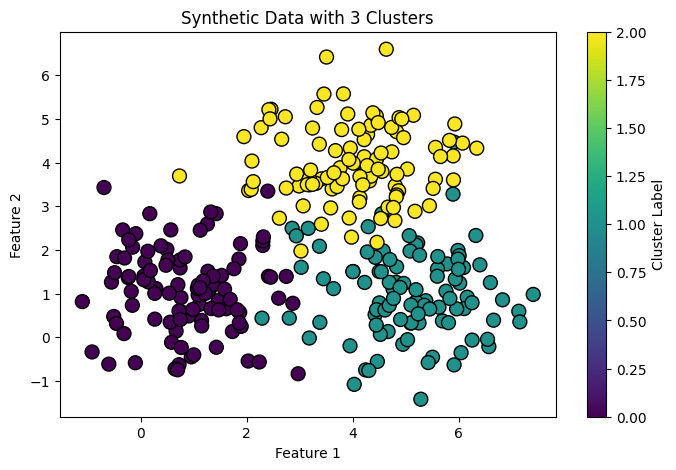

In [17]:
example = create_data(100)

data = example["data"]
labels = example["labels"]

fig = plt.figure(figsize=(8, 5))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="viridis", edgecolor="k", s=100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Data with 3 Clusters")
plt.colorbar(label="Cluster Label")

In [35]:
class Cluster_Sequential(nn.Module):
    def __init__(self, n_units, n_layers):
        super().__init__()
        
        layers = []
        
        # Hidden Layers
        for i in range(n_layers):
            if i==0:
                layers.append(nn.Linear(2, n_units)) # first hidden layer
            else:
                layers.append(nn.Linear(n_units, n_units))
            layers.append(nn.ReLU())
            
        # Output Layer
        layers.append(nn.Linear(n_units, 3))
        
        # Unpack the list into Sequential
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # No loop needed here! Sequential handles the flow.
        return self.model(x)
    
def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

In [ ]:
# the author of the eample here refers to number of layers without considering the first hidden layer
# therefore we correct later, and add 1 to the number of layers when creating the model.
num_layers = [1, 5, 10, 20]

total_units = 80
lr = 0.01
epochs = 50

loss_fn = nn.CrossEntropyLoss()

data_generated = create_data(200)
test_dl = data_generated["test_dl"]
train_dl = data_generated["train_dl"]

n_params = np.zeros(len(num_layers), dtype=int)
train_accuracies = np.zeros((len(num_layers), epochs))
test_accuracies = np.zeros((len(num_layers), epochs))

for i, n_layers in enumerate(num_layers):
    n_units = total_units // n_layers
    model = Cluster_Sequential(n_units, n_layers + 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)
    
    n_params[i] = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model with {n_layers} layers and {n_units} units per layer has {n_params[i]} parameters")
    train_accuracies[i, :] = train_acc
    test_accuracies[i, :] = test_acc

Model with 1 layers and 80 units per layer has 6963 parameters
Model with 5 layers and 16 units per layer has 1459 parameters
Model with 10 layers and 8 units per layer has 771 parameters
Model with 20 layers and 4 units per layer has 427 parameters


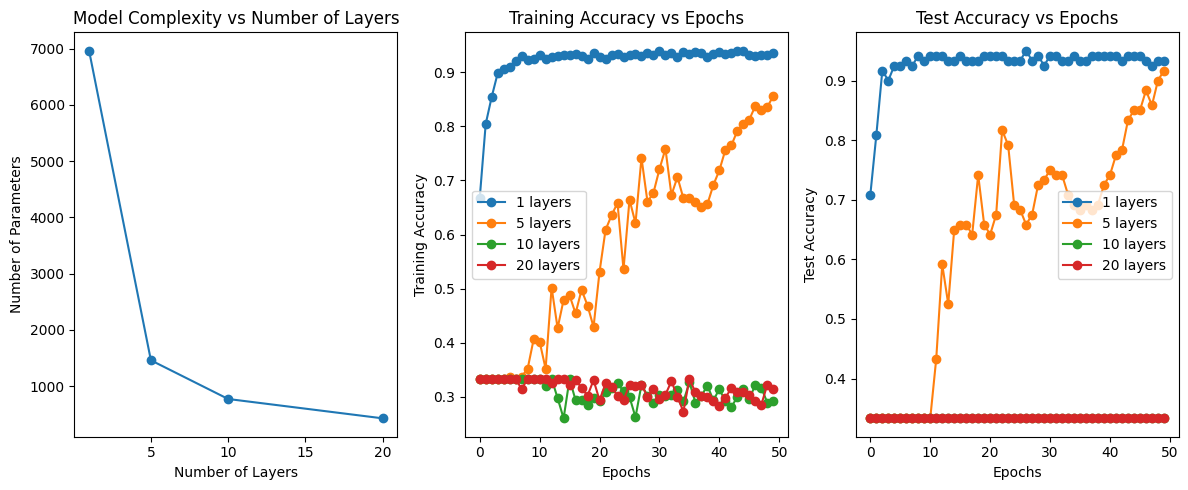

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].plot(num_layers, n_params, marker='o')
ax[0].set_xlabel("Number of Layers")
ax[0].set_ylabel("Number of Parameters")
ax[0].set_title("Model Complexity vs Number of Layers")

ax[1].plot(train_accuracies.T, marker='o')
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training Accuracy")
ax[1].set_title("Training Accuracy vs Epochs")
ax[1].legend([f"{n} layers" for n in num_layers])

ax[2].plot(test_accuracies.T, marker='o')
ax[2].set_xlabel("Epochs")
ax[2].set_ylabel("Test Accuracy")
ax[2].set_title("Test Accuracy vs Epochs")
ax[2].legend([f"{n} layers" for n in num_layers])

plt.tight_layout()
plt.show()

In [ ]:
# We observe, that the deep neural networks is more suitable for more complex problems, here as it is a
# straightforward problem, the shallow network performs better.